# Project

# Graph Stuff

In [4]:
from src.graphconstruction import GraphConstructor
from src.dataloading import DeepDataLoader, EpiDataLoader
from src.utils import get_data_env

modelname       = 'gatv2model'
disease_name    = 'influenza'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lags            = 1


# training hparams
n_epochs        = 100
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

epiloader = EpiDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epiloader.add_time_features()
epiloader.log_transform_target()
epiloader.set_splits(split_trainval, split_valtest)
epiloader.normalize()
epiloader.add_lagged_features(lags = lags)
epiloader.finalize()

epidata_loader_basis = DeepDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_basis.add_time_features()
epidata_loader_basis.log_transform_target()
epidata_loader_basis.set_splits(split_trainval, split_valtest)
epidata_loader_basis.normalize()
epidata_loader_basis.add_lagged_features(lags = lags)
epidata_loader_basis.finalize()

graphconstruction = GraphConstructor(epidata = epidata_loader_basis)
graphconstruction.generate_graph(
    method='identity', 
    self_connection='0'
    )

graphconstruction.generate_graph(
    method='boolean_neighbors', 
    self_connection='max',
)

graphconstruction.generate_graph(
    method='boolean_neighbors', 
    self_connection='0',
)
# long distance, sparse
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 3,
    alpha = 1,
    decay = 1,
    scaling_method='rowwise'
)

# long distance, dense
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 7,
    alpha = 1,
    decay = 1,
    scaling_method='rowwise',
    name_addition='2'
)

# more locally oriented, sparse
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 3,
    alpha = 2,
    decay = 1,
    scaling_method='rowwise',
    name_addition='3'
)


# more locally oriented, denser
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 7,
    alpha = 2,
    decay = 1,
    scaling_method='rowwise',
    name_addition='4'
)

graphconstruction.generate_graph(
    method='commuter', 
    self_connection='0',
    commuter_type = 'static',
    commuting_threshold = 1000,
    top_k = 4,
    scaling_method='rowwise',
    name_addition='1'
)

graphconstruction.generate_graph(
    method='commuter', 
    self_connection='mean',
    commuter_type = 'static',
    commuting_threshold = 1000,
    top_k = 4,
    scaling_method='rowwise',
    name_addition='2'
)

graphconstruction.generate_graph(
    method='commuter', 
    self_connection='0',
    commuter_type = 'static',
    commuting_threshold = 1000,
    scaling_method='rowwise',
    name_addition='3'
)

graphconstruction.generate_graph(
    method='commuter', 
    self_connection='mean',
    commuter_type = 'static',
    commuting_threshold = 1000,
    scaling_method='rowwise',
    name_addition='4'
)

graphconstruction.rename_graph('identity_self0',                'identity_graph')
graphconstruction.rename_graph('boolean_neighbors_selfmax',     'boolean_neighbors_self')
graphconstruction.rename_graph('boolean_neighbors_self0',       'boolean_neighbors_nonself')
graphconstruction.rename_graph('gravity_model_self0_rowwise',   'gravity1')
graphconstruction.rename_graph('gravity_model_2_self0_rowwise', 'gravity2')
graphconstruction.rename_graph('gravity_model_3_self0_rowwise', 'gravity3')
graphconstruction.rename_graph('gravity_model_4_self0_rowwise', 'gravity4')
graphconstruction.rename_graph('commuter_1_self0_rowwise',      'commuter1')
graphconstruction.rename_graph('commuter_2_selfmean_rowwise',   'commuter2')
graphconstruction.rename_graph('commuter_3_self0_rowwise',      'commuter3')
graphconstruction.rename_graph('commuter_4_selfmean_rowwise',   'commuter4')
graphconstruction.save_graph('all')

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
✓ graph generated: identity_self0
✓ graph generated: boolean_neighbors_selfmax
✓ graph generated: boolean_neighbors_self0
✓ graph generated: gravity_model_self0_rowwise
✓ graph generated: gravity_model_2_self0_rowwise
✓ graph generated: gravity_model_3_self0_rowwise
✓ graph generated: gravity_model_4_self0_rowwise
✓ graph generated: commuter_1_self0_rowwise
✓ graph generated: commuter_2_selfmean_rowwise
✓ graph generated: commuter_3_self0_rowwise
✓ graph generated: commuter_4_selfmean_rowwise
identity_self0 has been replaced by identity_graph
boolean_neighbors_selfmax has been replaced by boolean_neighbors_self
boolean_neighbors_self0 has been replaced by boolean_neighbors_nonself
gravity_model_self0_rowwise has been replaced by gravity1
gravit

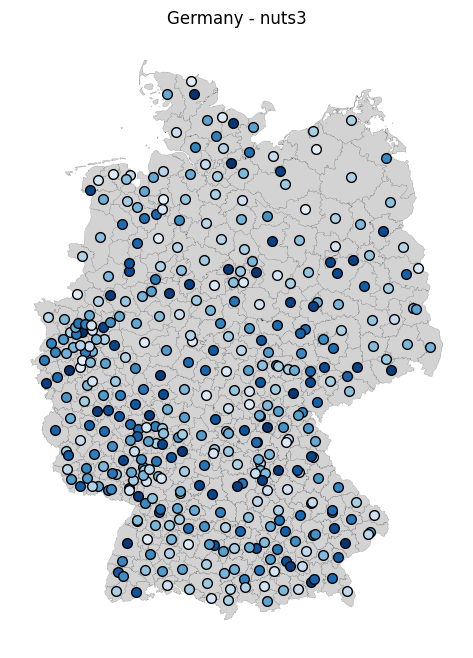

In [3]:
graphconstruction.preview_graph('empty')